<a href="https://colab.research.google.com/github/emilceinfante/4GeeksAcademy/blob/4geeks/Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import pandas as pd
import cv2
import numpy as np
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from PIL import Image


Contenido del directorio principal:
['test', 'train']

■ Datos de entrenamiento (7005 imágenes):
label
0    6245
1     760
Name: count, dtype: int64

■ Datos de prueba ({len(test_df)} imágenes):
label
0    2500
1    2500
Name: count, dtype: int64

Ejemplo de rutas:
Gato: /content/sample_data/CATS_VS_DOGS/train/cats/cat.6962.jpg
Perro: /content/sample_data/CATS_VS_DOGS/train/dogs/dog.142.jpg


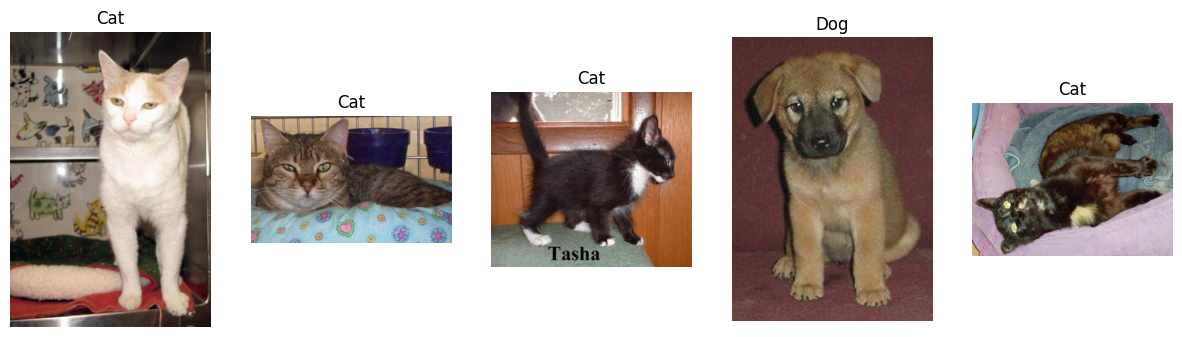

In [ ]:



# 1. Conexión con la ruta en Codespace - IMPORTANTE: ¡Ajusta esta ruta!
base_path = "/content/sample_data/cats_vs_dogs"  # Cambia esto a tu ruta real
data_dir = base_path  # Asumiendo esta estructura

# 2. Verificación de la estructura de carpetas
print("Contenido del directorio principal:")
print(os.listdir(base_path))

# 3. Función para crear el DataFrame
def create_image_dataframe(root_dir):
    """
    Crea un dataframe con las rutas de imágenes y sus etiquetas
    Args:
        root_dir: Directorio con subcarpetas 'train' y 'test'
                  cada una con subcarpetas 'cats' y 'dogs'
    Returns:
        DataFrames (train_df, test_df)
    """
    datasets = ['train', 'test']
    dataframes = []

    for dataset in datasets:
        image_paths = []
        labels = []

        # Construir rutas para cada clase
        for label in ['cats', 'dogs']:
            class_dir = os.path.join(root_dir, dataset, label)

            # Verificar si la carpeta existe
            if not os.path.exists(class_dir):
                raise FileNotFoundError(f"No se encontró: {class_dir}")

            # Procesar cada imagen
            for image_name in os.listdir(class_dir):
                if image_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                    image_paths.append(os.path.join(class_dir, image_name))
                    labels.append(0 if label == 'cats' else 1)  # 0=cat, 1=dog

        # Crear DataFrame
        df = pd.DataFrame({
            'image_path': image_paths,
            'label': labels,
            'dataset': dataset  # Para identificar train/test
        })
        dataframes.append(df)

    return dataframes[0], dataframes[1]  # train_df, test_df

# 4. Crear los DataFrames
try:
    train_df, test_df = create_image_dataframe(data_dir)

    # Mostrar información de los datos
    print(f"\n■ Datos de entrenamiento ({len(train_df)} imágenes):")
    print(train_df['label'].value_counts())
    print("\n■ Datos de prueba ({len(test_df)} imágenes):")
    print(test_df['label'].value_counts())

    # Mostrar ejemplo de imágenes
    print("\nEjemplo de rutas:")
    print("Gato:", train_df[train_df['label'] == 0]['image_path'].iloc[0])
    print("Perro:", train_df[train_df['label'] == 1]['image_path'].iloc[0])

    # Guardar los dataframes (opcional)
    train_df.to_csv("/content/sample_data/train_data.csv", index=False)
    test_df.to_csv("/content/sample_data/test_data.csv", index=False)

except Exception as e:
    print(f"\n❌ Error: {str(e)}")
    print("Verifica la estructura de tus carpetas:")
    print("Debe ser: cats_vs_dogs/{train,test}/{cats,dogs}/[imágenes]")

# 5. Visualización de ejemplo
def show_sample_images(df, num_samples=5):
    """Muestra muestras de imágenes del dataframe"""
    plt.figure(figsize=(15, 5))
    samples = df.sample(num_samples)

    for i, (_, row) in enumerate(samples.iterrows()):
        img = Image.open(row['image_path'])
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(img)
        plt.title("Cat" if row['label'] == 0 else "Dog")
        plt.axis('off')

    plt.show()

# Mostrar ejemplos (ejecutar solo si tienes interfaz gráfica)
try:
    show_sample_images(train_df)
except Exception as e:
    print("\n(No se pudo mostrar imágenes en este entorno)")
    print(f"Error: {str(e)}")


In [ ]:
import os
print("train_data.csv existe:", os.path.exists("/content/sample_data/train_data.csv"))
print("test_data.csv existe:", os.path.exists("/content/sample_data/test_data.csv"))


train_data.csv existe: True
test_data.csv existe: True


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

train_data = pd.read_csv("/content/sample_data/train_data.csv")
test_data = pd.read_csv("/content/sample_data/test_data.csv")

df = pd.concat([train_data, test_data], ignore_index=True)

# Definir X (características) y y (etiquetas)
X = df['image_path']  # Rutas de las imágenes
y = df['label']       # Etiquetas

# Dividir el DataFrame en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)




In [ ]:
X_train.info()

<class 'pandas.core.series.Series'>
Index: 9604 entries, 10909 to 7270
Series name: image_path
Non-Null Count  Dtype 
--------------  ----- 
9604 non-null   object
dtypes: object(1)
memory usage: 150.1+ KB


In [ ]:
X_test.info()

<class 'pandas.core.series.Series'>
Index: 2401 entries, 7740 to 7628
Series name: image_path
Non-Null Count  Dtype 
--------------  ----- 
2401 non-null   object
dtypes: object(1)
memory usage: 37.5+ KB


In [ ]:
y_train.info()

<class 'pandas.core.series.Series'>
Index: 9604 entries, 10909 to 7270
Series name: label
Non-Null Count  Dtype
--------------  -----
9604 non-null   int64
dtypes: int64(1)
memory usage: 150.1 KB


In [ ]:
y_test.info()

<class 'pandas.core.series.Series'>
Index: 2401 entries, 7740 to 7628
Series name: label
Non-Null Count  Dtype
--------------  -----
2401 non-null   int64
dtypes: int64(1)
memory usage: 37.5 KB


In [ ]:
!pip install tensorflow


 Inicialización y entrenamiento del modelo

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# Configuración inicial
IMAGE_SIZE = (150, 150)
BATCH_SIZE = 32
EPOCHS = 30
TRAIN_PATH = '/content/sample_data/cats_vs_dogs/train'  # Ruta de entrenamiento
TEST_PATH = '/content/sample_data/cats_vs_dogs/test'    # Ruta de prueba

# Generador de datos para entrenamiento con aumento de datos
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2)  # Usaremos 20% de los datos de entrenamiento como validación

# Generador de datos para prueba
test_datagen = ImageDataGenerator(rescale=1./255)

# Generador para datos de entrenamiento
train_generator = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training')  # Este es el conjunto de entrenamiento

# Generador para datos de validación (extraídos del conjunto de entrenamiento)
validation_generator = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation')  # Este es el conjunto de validación

# Generador para datos de prueba
test_generator = test_datagen.flow_from_directory(
    TEST_PATH,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False)

# Modelo CNN
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dropout(0.5),
    Dense(512, activation='relu'),
    Dense(1, activation='sigmoid')  # Salida binaria para perros vs gatos
])

# Compilar el modelo
model.compile(loss='binary_crossentropy',
              optimizer=Adam(learning_rate=1e-4),
              metrics=['accuracy'])

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True)
]

# Entrenamiento
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE,
    callbacks=callbacks,
    verbose=1)

# Evaluación en el conjunto de prueba
test_loss, test_acc = model.evaluate(test_generator)
print(f"\nPrecisión en el conjunto de prueba: {test_acc*100:.2f}%")


Found 5604 images belonging to 3 classes.
Found 1401 images belonging to 3 classes.
Found 5000 images belonging to 3 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8831 - loss: -11229.1475

175/175 ━━━━━━━━━━━━━━━━━━━━ 212s 1s/step - accuracy: 0.8832 - loss: -11671.2910 - val_accuracy: 0.8895 - val_loss: -772680.8750
Epoch 2/30
  1/175 ━━━━━━━━━━━━━━━━━━━━ 2:40 920ms/step - accuracy: 0.8750 - loss: -881187.7500

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


...

175/175 ━━━━━━━━━━━━━━━━━━━━ 17s 92ms/step - accuracy: 0.9062 - loss: -6679615766528.0000 - val_accuracy: 0.8910 - val_loss: -6886269124608.0000
Epoch 27/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 999ms/step - accuracy: 0.8956 - loss: -6971761623040.0000 

175/175 ━━━━━━━━━━━━━━━━━━━━ 261s 1s/step - accuracy: 0.8956 - loss: -6977828159488.0000 - val_accuracy: 0.8917 - val_loss: -9781979906048.0000
Epoch 28/30
  1/175 ━━━━━━━━━━━━━━━━━━━━ 2:29 857ms/step - accuracy: 0.9375 - loss: -6105689227264.0000

175/175 ━━━━━━━━━━━━━━━━━━━━ 21s 113ms/step - accuracy: 0.9375 - loss: -6105689227264.0000 - val_accuracy: 0.8917 - val_loss: -9791410798592.0000
Epoch 29/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 984ms/step - accuracy: 0.8964 - loss: -10026424991744.0000

175/175 ━━━━━━━━━━━━━━━━━━━━ 223s 1s/step - accuracy: 0.8964 - loss: -10034245271552.0000 - val_accuracy: 0.8917 - val_loss: -13742651736064.0000
Epoch 30/30
  1/175 ━━━━━━━━━━━━━━━━━━━━ 2:30 868ms/step - accuracy: 0.7812 - loss: -27195997159424.0000

175/175 ━━━━━━━━━━━━━━━━━━━━ 17s 95ms/step - accuracy: 0.7812 - loss: -27195997159424.0000 - val_accuracy: 0.8910 - val_loss: -13864552890368.0000
157/157 ━━━━━━━━━━━━━━━━━━━━ 46s 290ms/step - accuracy: 0.8412 - loss: -20012830031872.0000

Precisión en el conjunto de prueba: 50.00%


In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.regularizers import l2

# Configuración inicial
IMAGE_SIZE = (150, 150)
BATCH_SIZE = 32
EPOCHS = 30
TRAIN_PATH = '/content/sample_data/cats_vs_dogs/train'  # Ruta de entrenamiento
TEST_PATH = '/content/sample_data/cats_vs_dogs/test'    # Ruta de prueba

# Generador de datos para entrenamiento con aumento de datos
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2)  # Usaremos 20% de los datos de entrenamiento como validación

# Generador de datos para prueba
test_datagen = ImageDataGenerator(rescale=1./255)

# Generador para datos de entrenamiento
train_generator = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training')  # Este es el conjunto de entrenamiento

# Generador para datos de validación (extraídos del conjunto de entrenamiento)
validation_generator = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation')  # Este es el conjunto de validación

# Generador para datos de prueba
test_generator = test_datagen.flow_from_directory(
    TEST_PATH,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False)

# Modelo CNN
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3), kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu', kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu', kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu', kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Flatten(),
    Dropout(0.5),
    Dense(512, activation='relu', kernel_regularizer=l2(0.01)),
    Dense(1, activation='sigmoid')  # Salida binaria para perros vs gatos
])

# Compilar el modelo
model.compile(loss='binary_crossentropy',
              optimizer=Adam(learning_rate=1e-4),
              metrics=['accuracy'])

# Early Stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Entrenamiento
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE,
    callbacks=[early_stopping],
    verbose=1)

# Evaluación en el conjunto de prueba
test_loss, test_acc = model.evaluate(test_generator)
print(f"\nPrecisión en el conjunto de prueba: {test_acc*100:.2f}%")


Found 3828 images belonging to 3 classes.
Found 956 images belonging to 3 classes.
Found 3906 images belonging to 3 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 336s 3s/step - accuracy: 0.5225 - loss: -119.5225 - val_accuracy: 0.0000e+00 - val_loss: 62.6009
Epoch 2/30
  1/119 ━━━━━━━━━━━━━━━━━━━━ 4:15 2s/step - accuracy: 0.3438 - loss: -1050.0020

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


119/119 ━━━━━━━━━━━━━━━━━━━━ 24s 185ms/step - accuracy: 0.3438 - loss: -1050.0020 - val_accuracy: 0.0000e+00 - val_loss: 63.2705
Epoch 3/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 382s 3s/step - accuracy: 0.5223 - loss: -1170.8289 - val_accuracy: 0.0000e+00 - val_loss: 44.0500
Epoch 4/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 24s 185ms/step - accuracy: 0.6875 - loss: -1910.9404 - val_accuracy: 0.0000e+00 - val_loss: 43.6312
Epoch 5/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 382s 3s/step - accuracy: 0.5168 - loss: -3184.1702 - val_accuracy: 0.2392 - val_loss: -411.4373
Epoch 6/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 24s 183ms/step - accuracy: 0.3750 - loss: -6477.8979 - val_accuracy: 0.2403 - val_loss: -434.9975
Epoch 7/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 381s 3s/step - accuracy: 0.5098 - loss: -6378.7959 - val_accuracy: 0.4957 - val_loss: -3631.7341
Epoch 8/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 24s 183ms/step - accuracy: 0.3750 - loss: -11798.8311 - val_accuracy: 0.5054 - val_loss: -3622.2781
Epoch 9/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 36